In [20]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Настройки визуализации
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (7, 5)

In [21]:
# Загрузка данных
churn_data = pd.read_csv('data/churn.csv')

# Удаляем столбец RowNumber (лишняя информация)
if 'RowNumber' in churn_data.columns:
    churn_data = churn_data.drop(columns=['RowNumber'])

# Быстрый осмотр
display(churn_data.head())
display(churn_data.info())
display(churn_data.describe(include='all'))

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB


None

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [22]:
# 9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

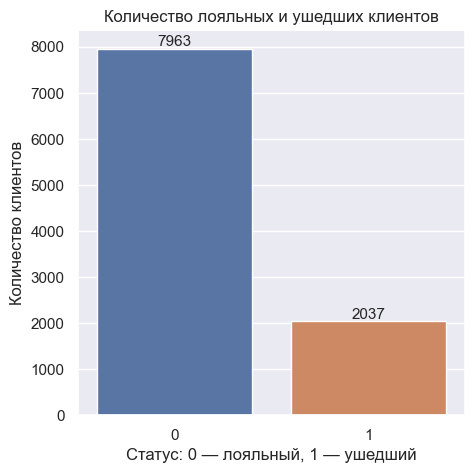

Доли клиентов:
-лояльные (0): 79.6%
-ушедшие (1):  20.4%


In [23]:
plt.figure(figsize=(5,5))
ax = sns.countplot(data=churn_data, x='Exited', hue='Exited', legend=False)
plt.title('Количество лояльных и ушедших клиентов')
plt.xlabel('Статус: 0 — лояльный, 1 — ушедший')
plt.ylabel('Количество клиентов')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.show()

# Доли
exit_count = churn_data['Exited'].value_counts(normalize=True) * 100
print("Доли клиентов:")
print(f"-лояльные (0): {exit_count.get(0,0):.1f}%")
print(f"-ушедшие (1):  {exit_count.get(1,0):.1f}%")

In [24]:
# Выводы:
# основная доля клиентов приходится на лояльных (~80%), при этом 20% клиентов ушли;
# отток клиентов (~20%) может свидетельствовать о наличии проблем / недостатков в процессе, которые приводят к уходу клиентов.

In [25]:
# 9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов.
# Опишите распределение и сделайте выводы.

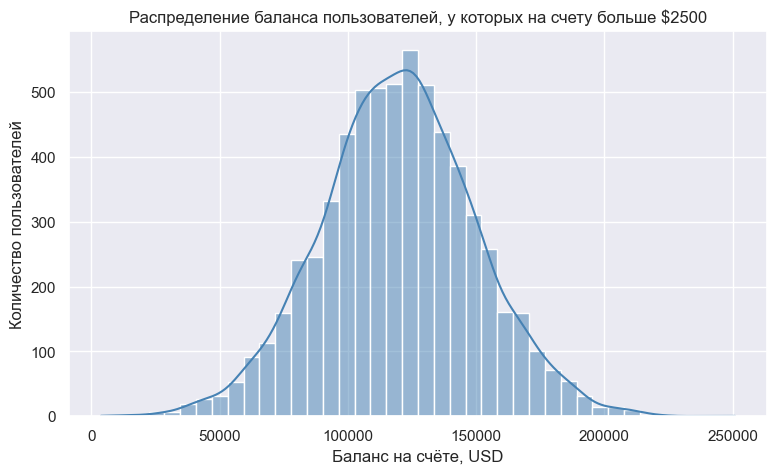

Описание / статистика (Balance > 2500):


count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: Balance, dtype: float64

In [26]:
data_bal_ov2500 = churn_data[churn_data['Balance'] > 2500].copy()

plt.figure(figsize=(9,5))
sns.histplot(data=data_bal_ov2500, x='Balance', bins=40, kde=True, color='steelblue')
plt.title('Распределение баланса пользователей, у которых на счету больше $2500')
plt.xlabel('Баланс на счёте, USD')
plt.ylabel('Количество пользователей')
plt.show()

print("Описание / статистика (Balance > 2500):")
display(data_bal_ov2500['Balance'].describe())

In [27]:
# Вывод:
# Распределение практически симметричное, среднее значение и медиана практически равны.
# Максимальное значение остатка составляет ~251 тыс USD (выброс), доля таких клиентов минимальна, что свидетельствует об отсутсвтии 
# у состоятельных клиентов заинтересованности в обслуживании в Банке / в размещении больших остатков в Банке.

In [28]:
# 9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном
# счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать
# ушедших клиентов в банке.

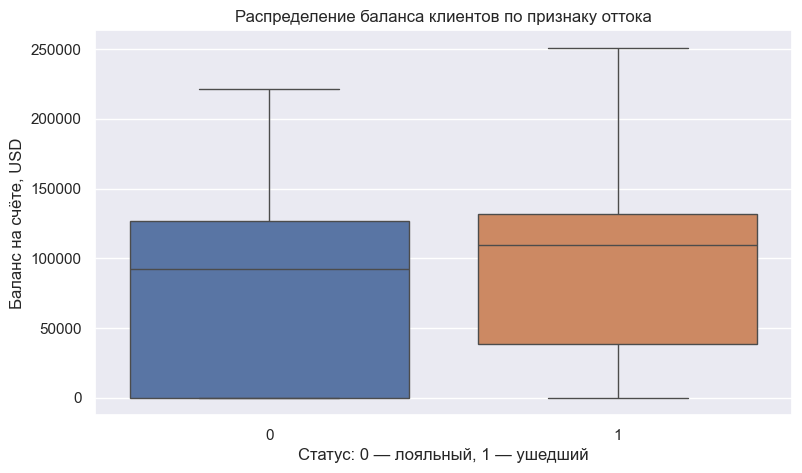

Средний баланс:
Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

Медианный баланс:
Exited
0     92072.68
1    109349.29
Name: Balance, dtype: float64


In [29]:
plt.figure(figsize=(9,5))
sns.boxplot(data=churn_data, x='Exited', y='Balance', hue='Exited', legend=False)
plt.title('Распределение баланса клиентов по признаку оттока')
plt.xlabel('Статус: 0 — лояльный, 1 — ушедший')
plt.ylabel('Баланс на счёте, USD')
plt.show()

# Сравнение средних/медиан
print("Средний баланс:")
print(churn_data.groupby('Exited')['Balance'].mean())
print("\nМедианный баланс:")
print(churn_data.groupby('Exited')['Balance'].median())

In [30]:
# Вывод:
# Средний и медианный баланс у ушедших клиентов выше по сравнению с лояльными клиентами, что может указывать на 
# наличие более выгодных условий по вкладам / накопительным счетам у банков-конкурентов, что приводит к переходу в
# другие банки. Возможно банки-конкуренты активно продвигают / предлагают привелегии для состоятельных клиентов (программа лояльности).

In [31]:
# 9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? 
# На какую возрастную категорию клиентов стоит обратить внимание банку?

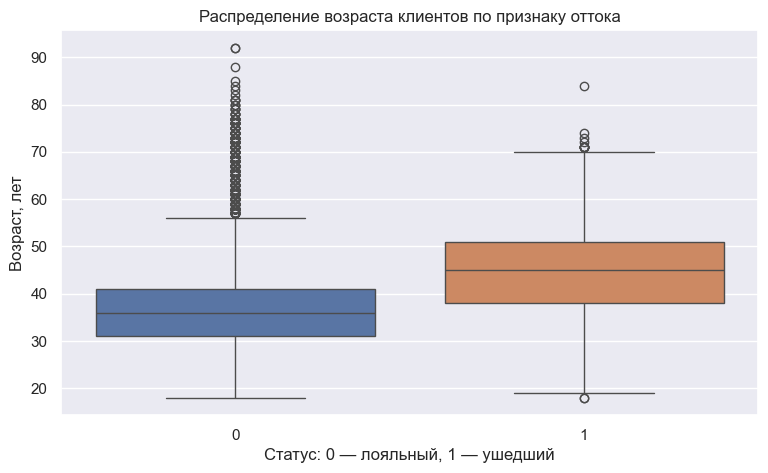

Количество выбросов по возрасту:
Лояльные (0): 486
Ушедшие (1):  13

Средний возраст по группам:
Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64


In [32]:
plt.figure(figsize=(9,5))
sns.boxplot(data=churn_data, x='Exited', y='Age', hue='Exited', legend=False)
plt.title('Распределение возраста клиентов по признаку оттока')
plt.xlabel('Статус: 0 — лояльный, 1 — ушедший')
plt.ylabel('Возраст, лет')
plt.show()

# Оценка выбросов по IQR
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3-q1
    lower, upper = q1-1.5*iqr, q3+1.5*iqr
    return ((series < lower) | (series > upper)).sum()

print("Количество выбросов по возрасту:")
print("Лояльные (0):", count_outliers(churn_data.loc[churn_data['Exited']==0, 'Age']))
print("Ушедшие (1): ", count_outliers(churn_data.loc[churn_data['Exited']==1, 'Age']))

# Возрастные категории с повышенным оттоком
print("\nСредний возраст по группам:")
print(churn_data.groupby('Exited')['Age'].mean())

In [33]:
# Вывод:
# Средний возраст уходящих клиентов выше, чем у лояльных, что может подтверждать гипотезу об уходе состоятельных клиентов.
# Количество выбросов у ушедших клиентов значительно меньше, чем у лояльных, что указавает на необходимость детального 
# анализа потребностей клиентов в возрасте ~40-50 лет.

In [34]:
# 9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты.
# Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи,
# укажите это.

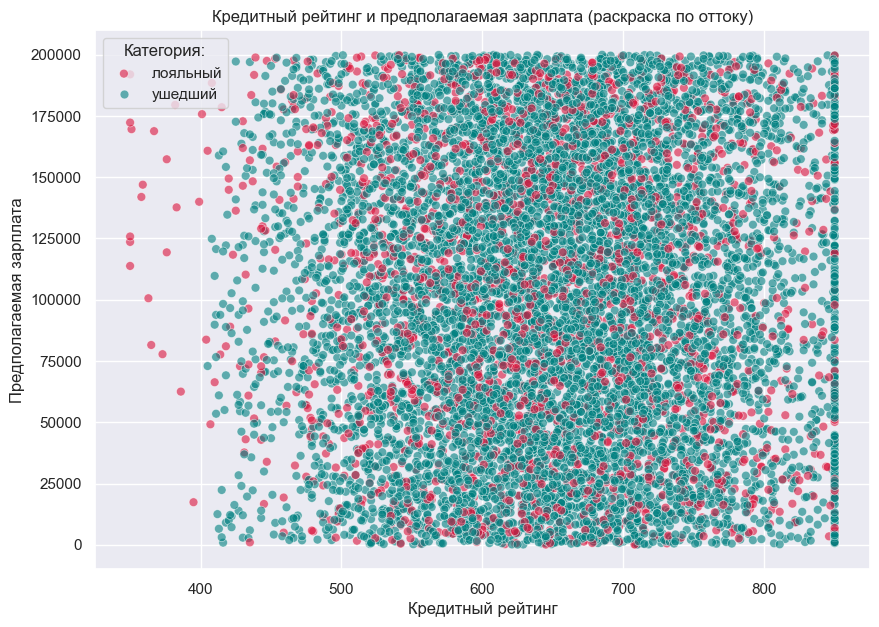

Корреляция между кредитным рейтингом и предполагаемой зарплатой: -0.001


In [35]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=churn_data,
    x='CreditScore',
    y='EstimatedSalary',
    hue='Exited',
    palette={0:'teal', 1:'crimson'},
    alpha=0.6,
    s=40
)
plt.title('Кредитный рейтинг и предполагаемая зарплата (раскраска по оттоку)')
plt.xlabel('Кредитный рейтинг')
plt.ylabel('Предполагаемая зарплата')
plt.legend(title='Категория:', labels=['лояльный', 'ушедший'])
plt.show()

# Оценка корреляции
corr = churn_data[['CreditScore','EstimatedSalary']].corr().iloc[0,1]
print(f"Корреляция между кредитным рейтингом и предполагаемой зарплатой: {corr:.3f}")

In [36]:
# Вывод:
# Корреляция практически отсутствует (-0,001). Ушедшие клиенты распределяются правктически по всем диапазонам кредитного рейтнига и зарплаты. 
# Соответственно, отток клиентов не связан с кредитным рейтингом и зарпалатой и не вызван возможностью (отсутствием) кредитования в Банке.

In [37]:
# 9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

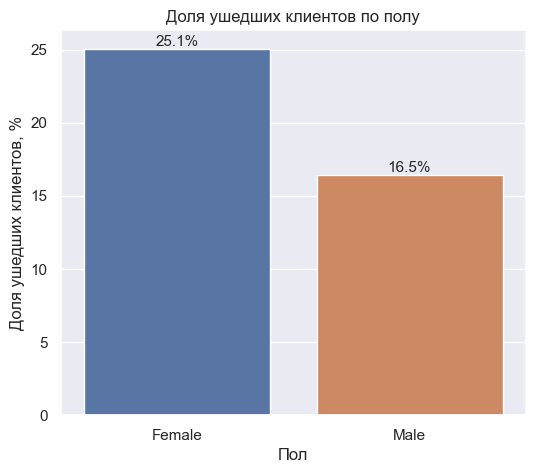

   Gender    Exited  Exited_rate_pct
0  Female  0.250715        25.071539
1    Male  0.164559        16.455928


In [38]:
# Доля ушедших по полу
gender_exit_rate = churn_data.groupby('Gender')['Exited'].mean().reset_index()
gender_exit_rate['Exited_rate_pct'] = gender_exit_rate['Exited'] * 100

plt.figure(figsize=(6,5))
sns.barplot(data=gender_exit_rate, x='Gender', y='Exited_rate_pct', hue='Gender', legend=False)
plt.title('Доля ушедших клиентов по полу')
plt.xlabel('Пол')
plt.ylabel('Доля ушедших клиентов, %')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.show()

print(gender_exit_rate)

In [39]:
# Вывод:
# По результатам анализа установлено, что женщины уходят чаще (доля выше на 8,6 п.п. по сравнению с мужчинами).
# Это может указывать на наличие проблем в качестве сервиса в Банке, а также на наличие более выгодных предложений для женщин в других банках.
# Банку необходимо получить обратную связь о причинах ухода от женщин, что позволит принять / разработать эффективные меры по удержанию клиентов.

In [40]:
# 9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.

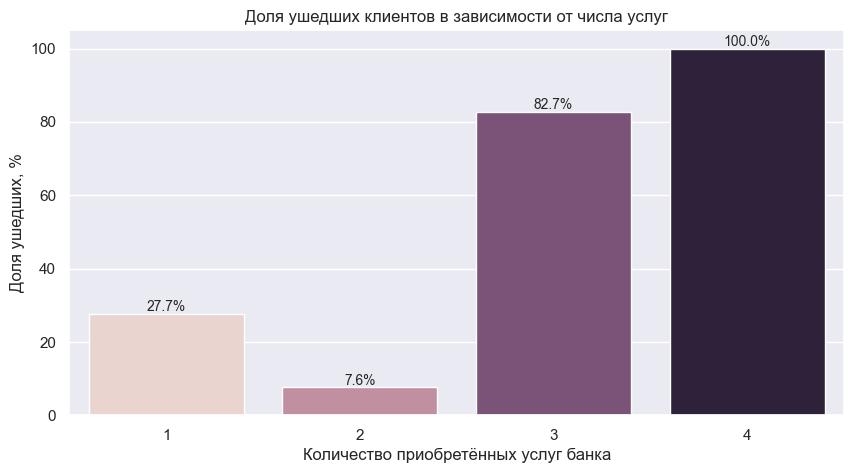

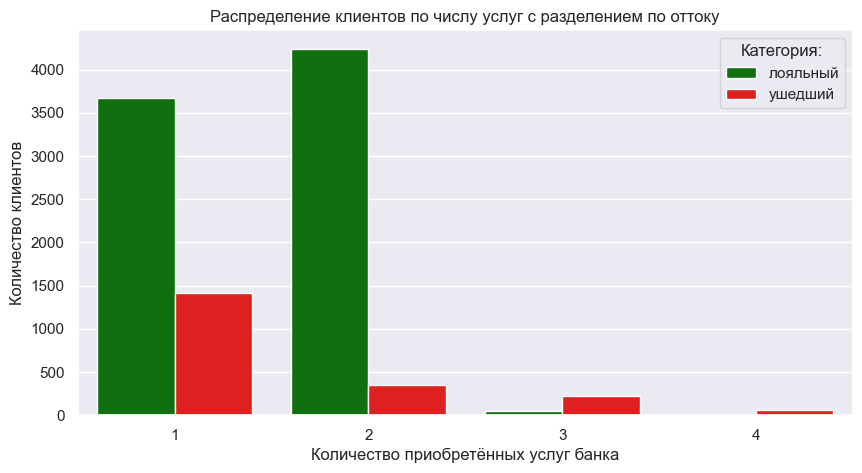

In [41]:
# Доля ушедших по количеству продуктов
prod_exit_rate = churn_data.groupby('NumOfProducts')['Exited'].mean().reset_index()
prod_exit_rate['Exited_rate_pct'] = prod_exit_rate['Exited'] * 100

plt.figure(figsize=(10,5))
sns.barplot(data=prod_exit_rate, x='NumOfProducts', y='Exited_rate_pct', hue='NumOfProducts', legend=False)
plt.title('Доля ушедших клиентов в зависимости от числа услуг')
plt.xlabel('Количество приобретённых услуг банка')
plt.ylabel('Доля ушедших, %')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.show()

# Распределение клиентов по числу продуктов
plt.figure(figsize=(10,5))
sns.countplot(data=churn_data, x='NumOfProducts', hue='Exited', palette={0:'green', 1:'red'})
plt.title('Распределение клиентов по числу услуг с разделением по оттоку')
plt.xlabel('Количество приобретённых услуг банка')
plt.ylabel('Количество клиентов')
plt.legend(title='Категория:', labels=['лояльный', 'ушедший'])
plt.show()

In [42]:
# Вывод:
# Клиенты, которые пользуются 1-2 продуктами (услугами) уходят реже, соответственно основной продукт (услуга) соответствует ожиданиям клиентов.
# При этом клиенты, которые пользовались 4 продуктами (услугами) полностью ушли из Банка, а количество оставшихся клиентов с 3 продуктами минимально.
# Банку необходимо оценить качество продуктов (услуг) и их сопровождения в отношении ушедших клиентов (с 3-4 продуктами).
# Также необходимо проверить качество продаж (наличие "мисселнига") по кросс-продажам (продажа доп.продуктов).
# Отток клиентов, использующих 3-4 продукта может указывать на отсутствие комплексных (пакетных) предложений или их несоответствие условиям на рынке.

In [43]:
# 9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму,
# иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?

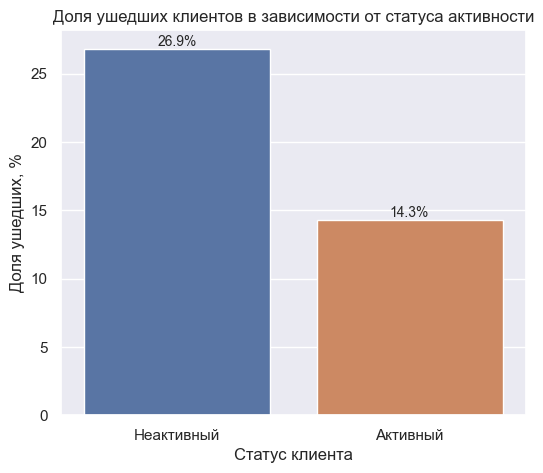

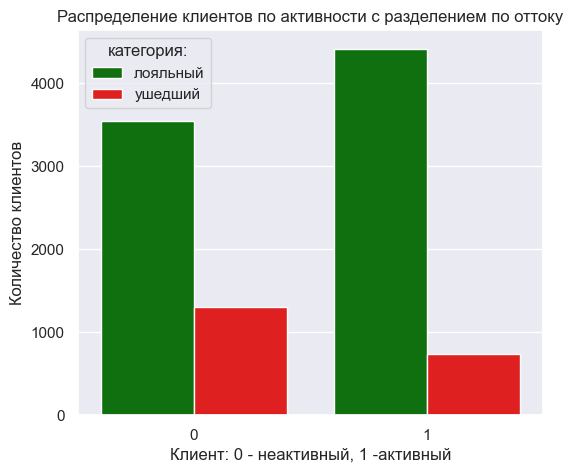

In [44]:
# Доля ушедших по активности
active_exit_rate = churn_data.groupby('IsActiveMember')['Exited'].mean().reset_index()
active_exit_rate['Exited_rate_pct'] = active_exit_rate['Exited'] * 100
active_exit_rate['IsActiveMember'] = active_exit_rate['IsActiveMember'].map({0:'Неактивный', 1:'Активный'})

plt.figure(figsize=(6,5))
sns.barplot(data=active_exit_rate, x='IsActiveMember', y='Exited_rate_pct', hue='IsActiveMember', legend=False)
plt.title('Доля ушедших клиентов в зависимости от статуса активности')
plt.xlabel('Статус клиента')
plt.ylabel('Доля ушедших, %')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.show()

# Распределение
plt.figure(figsize=(6,5))
sns.countplot(data=churn_data, x='IsActiveMember', hue='Exited', palette={0:'green', 1:'red'})
plt.title('Распределение клиентов по активности с разделением по оттоку')
plt.xlabel('Клиент: 0 - неактивный, 1 -активный')
plt.ylabel('Количество клиентов')
plt.legend(title='категория:', labels=['лояльный', 'ушедший'])
plt.show()

In [45]:
# Вывод:
# Неактивные клиенты уходят чаще, чем активные. Может быть связано с оптимизацией действующих счетов / карт (неиспользуемых).
# Также это может быть следствием качества продукта (услуги) / сервиса обслуживания, клиент перестает пользоваться услугой и позже уходит.
# Банку рекомендуется оценить соответствие услуг (продуктов) и уровня сервиса условиям рынка, принять меры направленные на их улучшение.
# После проведения анализа и доработки услуг (продуктов) и уровня сервиса, рекомендуется провести CRM-компанию, 
# направленную на активацию "спящих" клиентов.
# Для пользователей мобильного (интернет) банка включить push-уведомления о новых продуктах / услугах, а также о запуске новой программы лояльности.

In [46]:
# 9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму,
# которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.

C:\Users\YoY\AppData\Local\Temp\ipykernel_5248\2525490692.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


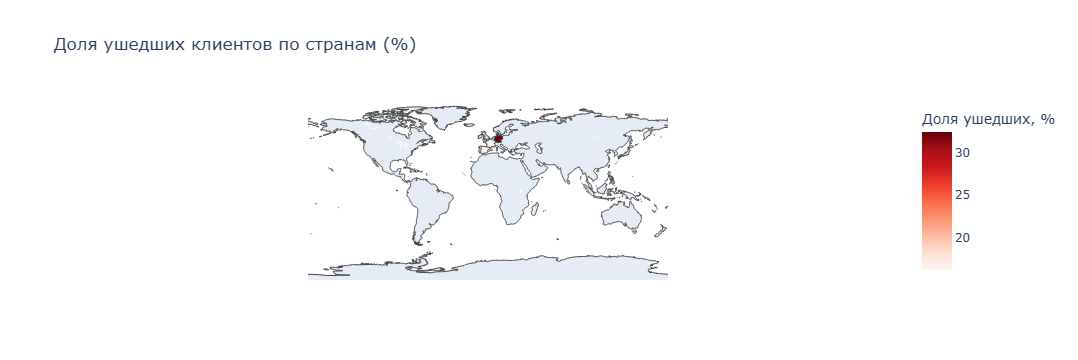

In [47]:
# Доля ушедших по странам
country_exit_rate = churn_data.groupby('Geography')['Exited'].mean().reset_index()
country_exit_rate['Exited_rate_pct'] = country_exit_rate['Exited'] * 100
country_exit_rate.rename(columns={'Geography':'Country'}, inplace=True)

# Построение тепловой картограммы
fig = px.choropleth(
    country_exit_rate,
    locations='Country',
    locationmode='country names',
    color='Exited_rate_pct',
    color_continuous_scale='Reds',
    title='Доля ушедших клиентов по странам (%)',
    labels={'Exited_rate_pct':'Доля ушедших, %'}
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

In [48]:
# Вывод:
# Наибольшая доля ушедших клиентов в Германии (32%), доля ушедших во Франции и Испании меньше и составляет по 16%.

# Предположения:
# В Германии банковский сектор представлен большим числом банков, соответственно уровень конкуренции выше и банки-конкуренты предположительно активно
# предлагают клиентам новые продукты / привилегии, возможно предоставляют улучшенный сервис, что усиливает отток из Банка.

In [49]:
# 9.10. Переведите числовой признак CreditScore в категориальный. Для этого воспользуйтесь функцией
# get_credit_score_cat(), которая приведена ниже. Примените её к столбцу CreditScore и создайте новый
# признак CreditScoreCat — категории кредитного рейтинга.
# Постройте сводную таблицу, строками которой являются категории кредитного рейтинга (CreditScoreCat),
# а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure).
# В ячейках сводной таблицы должно находиться среднее по признаку оттока (Exited) — доля ушедших пользователей.

# На основе полученной сводной таблицы постройте тепловую карту с аннотацией. Найдите на тепловой карте
# категории клиентов, которые уходят чаще всего.

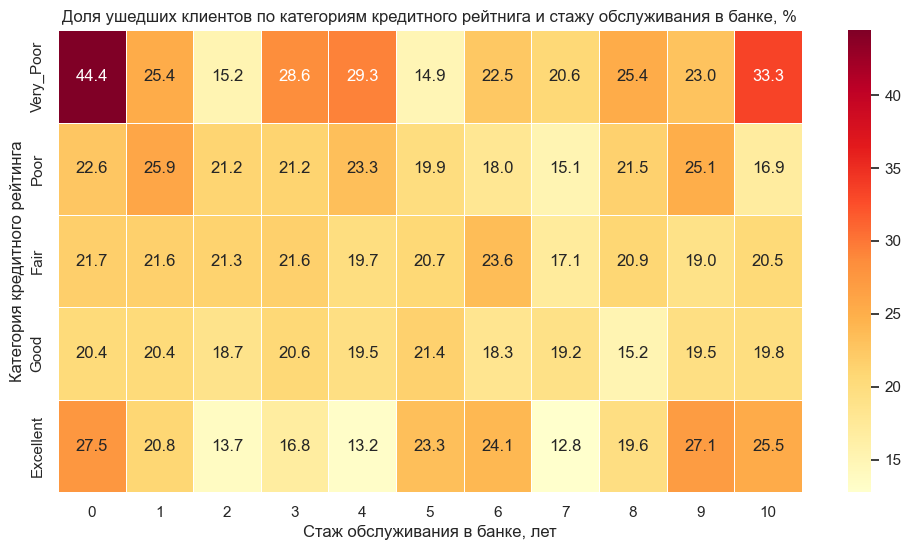

Средняя доля ушедших по категориям кредитного рейтинга (%):
CreditScoreCat
Very_Poor    25.7
Poor         21.0
Fair         20.7
Excellent    20.4
Good         19.4
dtype: float64

Категории с наибольшим оттоком (топ-3):
CreditScoreCat
Very_Poor    25.7
Poor         21.0
Fair         20.7
dtype: float64


In [50]:
# Функция категоризации по кредитному рейтингу
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

# Создаём новый признак CreditScoreCat
churn_data['CreditScoreCat'] = churn_data['CreditScore'].apply(get_credit_score_cat)

# Сводная таблица: строки — CreditScoreCat, столбцы — Tenure, значения — среднее Exited (доля ушедших)
pivot_exit = churn_data.pivot_table(
    index='CreditScoreCat',
    columns='Tenure',
    values='Exited',
    aggfunc='mean'
)

# Сортировка по уровню кредитного рейтинга
cat_order = ["Deep", "Very_Poor", "Poor", "Fair", "Good", "Excellent", "Top"]

# Оставим только те, что есть в данных
present_cats = [c for c in cat_order if c in pivot_exit.index]
pivot_exit = pivot_exit.reindex(present_cats)

# Тепловая карта
plt.figure(figsize=(12,6))
sns.heatmap(
    pivot_exit * 100,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title('Доля ушедших клиентов по категориям кредитного рейтнига и стажу обслуживания в банке, %')
plt.xlabel('Стаж обслуживания в банке, лет')
plt.ylabel('Категория кредитного рейтинга')
plt.show()

# Определение категорий кредитного рейтинга с наибольшим оттоком

avg_by_cat = pivot_exit.mean(axis=1).sort_values(ascending=False)
print("Средняя доля ушедших по категориям кредитного рейтинга (%):")
print((avg_by_cat * 100).round(1))

print("\nКатегории с наибольшим оттоком (топ-3):")
print((avg_by_cat.head(3) * 100).round(1))

In [51]:
# Вывод:
# Клиенты с очень плохим и плохим кредитным рейтнигом уходят из Банка чаще, что может быть связано с отказом в кредите.
# В 60% случаев отток клиентов не связан с кредитным рейтингом.
# Также отмечается, что стаж обслуживания в Банке не обеспечивает "привязанность" клиента к Банку, клиенты уходят независимо от стажа.
# Банку необходимо проработать возможность оказания услуг, направленных на повышение кредитного рейтинга клиентов, в т.ч. за счет небольших кредитов.